In [27]:
# 기본 라이브러리
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 머신러닝 관련 라이브러리
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# FutureWarning 무시
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load Data

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lavanyashukla01/particle-identification")

print("Path to dataset files:", path)

Path to dataset files: /Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1


In [4]:
import pandas as pd
import os

# 데이터 저장 경로 (사용자 환경에 따라 다를 수 있음)
base_path = "/Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1"


# 1. 폴더 안에 있는 파일 목록 확인
if os.path.exists(base_path):
    file_list = os.listdir(base_path)
    print("파일 목록:", file_list)
    
    # 2. CSV 파일 찾기 (보통 training.csv 또는 data.csv)
    csv_files = [f for f in file_list if f.endswith('.csv')]
    
    if len(csv_files) > 0:
        full_path1 = os.path.join(base_path, csv_files[0])
        full_path2 = os.path.join(base_path, csv_files[1])

        train_df = pd.read_csv(full_path1)
        test_df = pd.read_csv(full_path2)
        
        print(f"Load complete: \n Train : {train_df.shape}, Test : {test_df.shape}")
            
    else:
        print("❌ 폴더는 찾았지만, .csv 파일이 보이지 않습니다. 압축(.zip)이 덜 풀렸는지 확인이 필요합니다.")
else:
    print(f"❌ 경로를 찾을 수 없습니다: {base_path}")

파일 목록: ['training.csv', 'test.csv']
Load complete: 
 Train : (1200000, 50), Test : (1200000, 50)


# Data Preprocessing

## Data Overview

In [13]:
df_train = train_df.copy() ; df_test = test_df.copy()

In [14]:
# 데이터 구조 확인
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 50 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   TrackP                           1200000 non-null  float64
 1   TrackNDoFSubdetector2            1200000 non-null  float64
 2   BremDLLbeElectron                1200000 non-null  float64
 3   MuonLooseFlag                    1200000 non-null  float64
 4   FlagSpd                          1200000 non-null  float64
 5   SpdE                             1200000 non-null  float64
 6   EcalDLLbeElectron                1200000 non-null  float64
 7   DLLmuon                          1200000 non-null  float64
 8   RICHpFlagElectron                1200000 non-null  float64
 9   EcalDLLbeMuon                    1200000 non-null  float64
 10  TrackQualitySubdetector2         1200000 non-null  float64
 11  FlagPrs                          1200000 non-null 

In [15]:
# 데이터 확인
df_train.head()
# Head()를 통해 데이터 확인 후, -999와 같은 이상치 확인 => 이는 보통 NaN값 대신 채워지는 값으로, 이상치 처리 필요
# 이를 그대로 두가 정규화 할 경우, 분포가 심각하게 망가짐

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
0,74791.156263,15.0,0.232275,1.0,1.0,3.2,-2.505719,6.604153,1.0,1.929960,...,28.0,1.0,-7.213300,-0.280200,5586.589846,1.0,1.0,10.422315,-2.081143e-07,-24.824400
1,2738.489989,15.0,-0.357748,0.0,1.0,3.2,1.864351,0.263651,1.0,-2.061959,...,32.0,1.0,-0.324317,1.707283,-0.000007,0.0,1.0,43.334935,2.771583e+00,-0.648017
2,2161.409908,17.0,-999.000000,0.0,0.0,-999.0,-999.000000,-999.000000,0.0,-999.000000,...,27.0,0.0,-999.000000,-999.000000,-999.000000,0.0,0.0,-999.000000,-9.990000e+02,-999.000000
3,15277.730490,20.0,-0.638984,0.0,1.0,3.2,-2.533918,-8.724949,1.0,-3.253981,...,36.0,1.0,-35.202221,-14.742319,4482.803707,0.0,1.0,2.194175,-3.070819e+00,-29.291519
4,7563.700195,19.0,-0.638962,0.0,1.0,3.2,-2.087146,-7.060422,1.0,-0.995816,...,33.0,1.0,25.084287,-10.272412,5107.554680,0.0,1.0,0.000015,-5.373712e+00,23.653087


In [16]:
# 기초통계량 확인
df_train.describe()

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
count,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,...,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06
mean,1.614162e+04,1.475170e+01,-2.077315e+02,1.908400e-01,8.531908e-01,-1.443849e+02,-1.828275e+02,-1.266902e+01,9.514050e-01,-1.830022e+02,...,2.942221e+01,9.187425e-01,-5.183805e+01,-5.103860e+01,2.900030e+03,1.662333e-01,8.209933e-01,-1.338948e+02,-4.919965e+01,-5.223401e+01
std,2.790366e+04,4.038073e+00,4.054632e+02,3.929634e-01,3.539157e-01,3.545035e+02,3.854803e+02,1.049158e+02,2.150199e-01,3.853958e+02,...,6.029159e+00,2.732303e-01,2.153209e+02,2.150846e+02,7.686446e+03,3.722901e-01,3.833581e-01,3.628977e+02,2.147605e+02,2.152330e+02
min,1.115380e+03,1.000000e+00,-9.990000e+02,0.000000e+00,0.000000e+00,-9.990000e+02,-9.990000e+02,-9.990000e+02,0.000000e+00,-9.990000e+02,...,7.000000e+00,0.000000e+00,-9.990000e+02,-9.990000e+02,-9.990000e+02,0.000000e+00,0.000000e+00,-9.990000e+02,-9.990000e+02,-9.990000e+02
25%,4.137650e+03,1.300000e+01,-6.389485e-01,0.000000e+00,1.000000e+00,0.000000e+00,-3.000639e+00,-5.711142e+00,1.000000e+00,-3.367626e+00,...,2.600000e+01,1.000000e+00,-1.469941e+01,-1.310509e+01,-1.438680e-05,0.000000e+00,1.000000e+00,9.222748e-06,-4.503331e+00,-1.619484e+01
50%,8.069835e+03,1.600000e+01,-5.329026e-01,0.000000e+00,1.000000e+00,3.200000e+00,-2.321410e+00,-1.988139e+00,1.000000e+00,-1.956064e+00,...,3.000000e+01,1.000000e+00,-1.207258e-06,-2.356098e+00,5.780127e+02,0.000000e+00,1.000000e+00,2.468449e+00,-4.697510e-01,-2.928758e-06
75%,1.750157e+04,1.800000e+01,-5.933819e-02,0.000000e+00,1.000000e+00,3.200000e+00,5.918621e-01,1.669210e+00,1.000000e+00,4.339380e-01,...,3.400000e+01,1.000000e+00,8.465107e+00,1.674137e+00,3.046122e+03,0.000000e+00,1.000000e+00,8.502449e+00,1.300086e+00,8.922095e+00
max,4.750951e+06,3.000000e+01,4.791513e+00,1.000000e+00,1.000000e+00,3.200000e+00,4.341298e+00,1.471079e+01,1.000000e+00,2.153017e+00,...,5.200000e+01,1.000000e+00,1.588015e+02,1.861542e+02,8.682200e+05,1.000000e+00,1.000000e+00,2.805800e+02,1.428335e+02,1.462984e+02


In [20]:
# 컬럼명 확인
print(df_train.columns.tolist())

['TrackP', 'TrackNDoFSubdetector2', 'BremDLLbeElectron', 'MuonLooseFlag', 'FlagSpd', 'SpdE', 'EcalDLLbeElectron', 'DLLmuon', 'RICHpFlagElectron', 'EcalDLLbeMuon', 'TrackQualitySubdetector2', 'FlagPrs', 'DLLelectron', 'DLLkaon', 'EcalE', 'TrackQualityPerNDoF', 'DLLproton', 'PrsDLLbeElectron', 'FlagRICH1', 'MuonLLbeBCK', 'FlagHcal', 'EcalShowerLongitudinalParameter', 'Calo2dFitQuality', 'TrackPt', 'TrackDistanceToZ', 'RICHpFlagPion', 'HcalDLLbeElectron', 'Calo3dFitQuality', 'FlagEcal', 'MuonLLbeMuon', 'TrackNDoFSubdetector1', 'RICHpFlagProton', 'RICHpFlagKaon', 'GhostProbability', 'TrackQualitySubdetector1', 'Label', 'RICH_DLLbeBCK', 'FlagRICH2', 'FlagBrem', 'HcalDLLbeMuon', 'TrackNDoF', 'RICHpFlagMuon', 'RICH_DLLbeKaon', 'RICH_DLLbeElectron', 'HcalE', 'MuonFlag', 'FlagMuon', 'PrsE', 'RICH_DLLbeMuon', 'RICH_DLLbeProton']


In [35]:
# 결측치 확인
df_train.isnull().sum()

TrackP                             0
TrackNDoFSubdetector2              0
BremDLLbeElectron                  0
MuonLooseFlag                      0
FlagSpd                            0
SpdE                               0
EcalDLLbeElectron                  0
DLLmuon                            0
RICHpFlagElectron                  0
EcalDLLbeMuon                      0
TrackQualitySubdetector2           0
FlagPrs                            0
DLLelectron                        0
DLLkaon                            0
EcalE                              0
TrackQualityPerNDoF                0
DLLproton                          0
PrsDLLbeElectron                   0
FlagRICH1                          0
MuonLLbeBCK                        0
FlagHcal                           0
EcalShowerLongitudinalParameter    0
Calo2dFitQuality                   0
TrackPt                            0
TrackDistanceToZ                   0
RICHpFlagPion                      0
HcalDLLbeElectron                  0
C

In [21]:
# 중복 데이터 확인
df_train.duplicated().sum()

np.int64(0)

In [24]:
# 타겟 데이터 확인
print(df_train['Label'].unique())

['Muon' 'Ghost' 'Pion' 'Proton' 'Kaon' 'Electron']


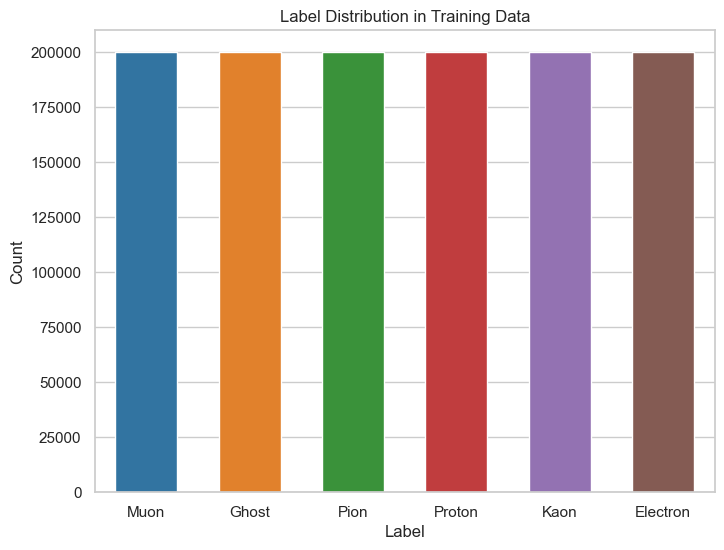

In [45]:
# 라벨 분포 시각화
plt.figure(figsize=(8,6))
sns.countplot(data=df_train, x='Label', palette='tab10', width=0.6)
plt.title('Label Distribution in Training Data')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

## EDA

In [ ]:
# 데이터가 물리적으로 정상적인지 확인 - 운동량(P), 전자기 에너지(Ecal), 하드론 에너지(Hcal) 간의 관계 시각화

/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


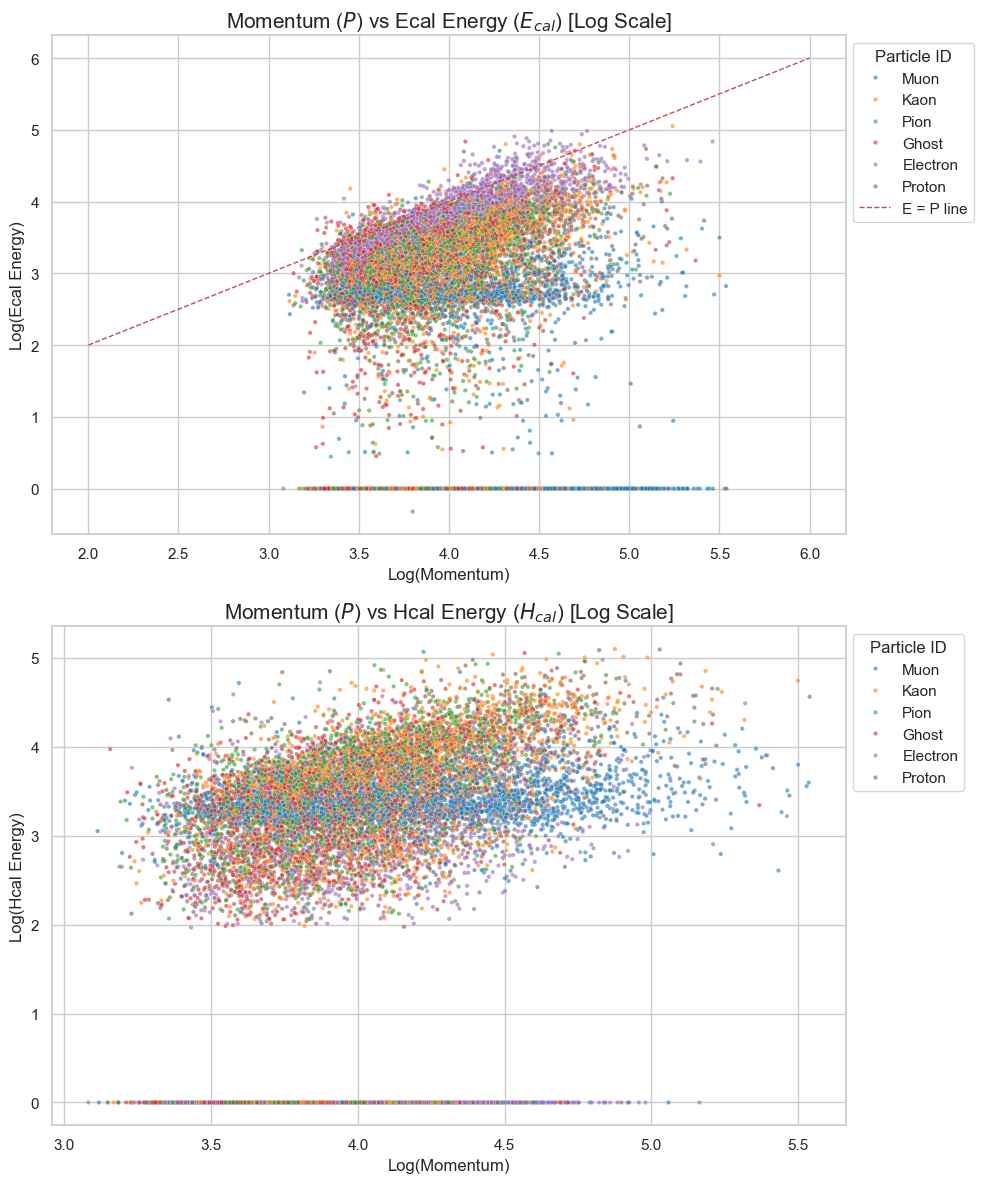

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 데이터 샘플링 (전체 데이터가 너무 크면 시각화가 느려지므로 1만~5만 개만 추출)
# 랜덤성을 고정하여 재현성 확보
df_sample = df_train.sample(n=20000, random_state=42).copy()

# 2. 로그 변환 (Log Transformation)
# 물리 데이터는 0이 포함될 수 있으므로 log(x + 1)을 적용하여 -inf 방지
# TrackP: 운동량, EcalE: 전자기 열량계 에너지, HcalE: 강입자 열량계 에너지
cols_to_log = ['TrackP', 'EcalE', 'HcalE']
for col in cols_to_log:
    df_sample[f'Log_{col}'] = np.log10(df_sample[col] + 1.0)

# 3. 시각화 설정
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Plot 1: 운동량(P) vs 전자기 에너지(Ecal)
# 기대: 전자는 대각선(P ~ E)에 위치, 강입자는 낮게 분포
sns.scatterplot(
    data=df_sample, 
    x='Log_TrackP', 
    y='Log_EcalE', 
    hue='Label', 
    palette='tab10', 
    s=10, 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('Momentum ($P$) vs Ecal Energy ($E_{cal}$) [Log Scale]', fontsize=15)
axes[0].set_xlabel('Log(Momentum)', fontsize=12)
axes[0].set_ylabel('Log(Ecal Energy)', fontsize=12)
axes[0].plot([2, 6], [2, 6], 'r--', lw=1, label='E = P line') # E=P 기준선 (대략적)
axes[0].legend(title='Particle ID', loc='upper left', bbox_to_anchor=(1, 1))

# Plot 2: 운동량(P) vs 강입자 에너지(Hcal)
# 기대: 강입자(Pion, Proton 등)는 대각선 인근 혹은 높게 분포, 전자/뮤온은 낮게 분포
sns.scatterplot(
    data=df_sample, 
    x='Log_TrackP', 
    y='Log_HcalE', 
    hue='Label', 
    palette='tab10', 
    s=10, 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Momentum ($P$) vs Hcal Energy ($H_{cal}$) [Log Scale]', fontsize=15)
axes[1].set_xlabel('Log(Momentum)', fontsize=12)
axes[1].set_ylabel('Log(Hcal Energy)', fontsize=12)
axes[1].legend(title='Particle ID', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

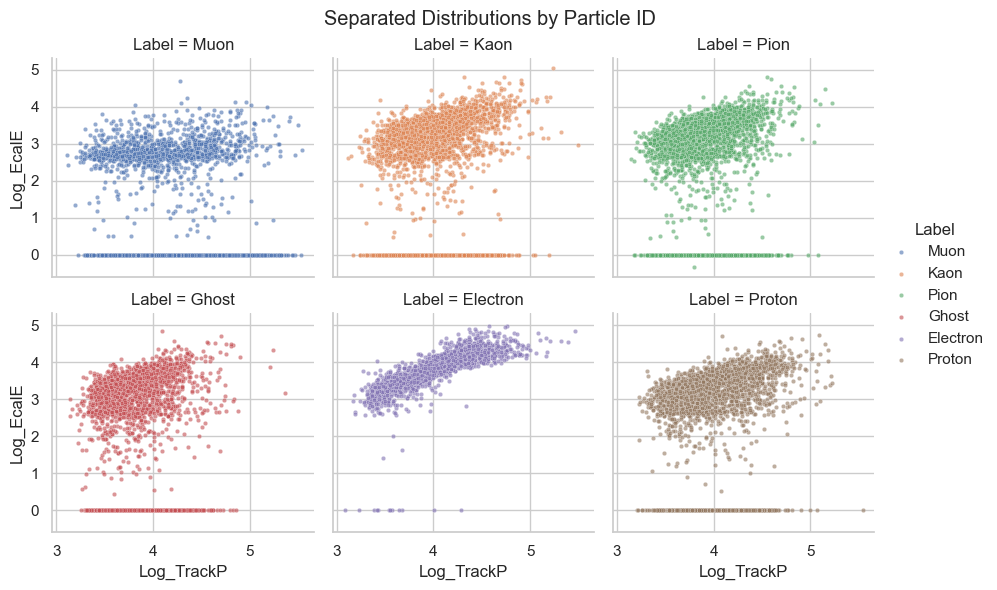

In [47]:
# 각 입자 종류(ID)별로 그래프를 따로 그림
g = sns.FacetGrid(df_sample, col='Label', col_wrap=3, hue='Label', sharey=True, sharex=True)
g.map(sns.scatterplot, "Log_TrackP", "Log_EcalE", s=10, alpha=0.6)
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Separated Distributions by Particle ID')
plt.show()

t-SNE 계산 중... 잠시만 기다려주세요.


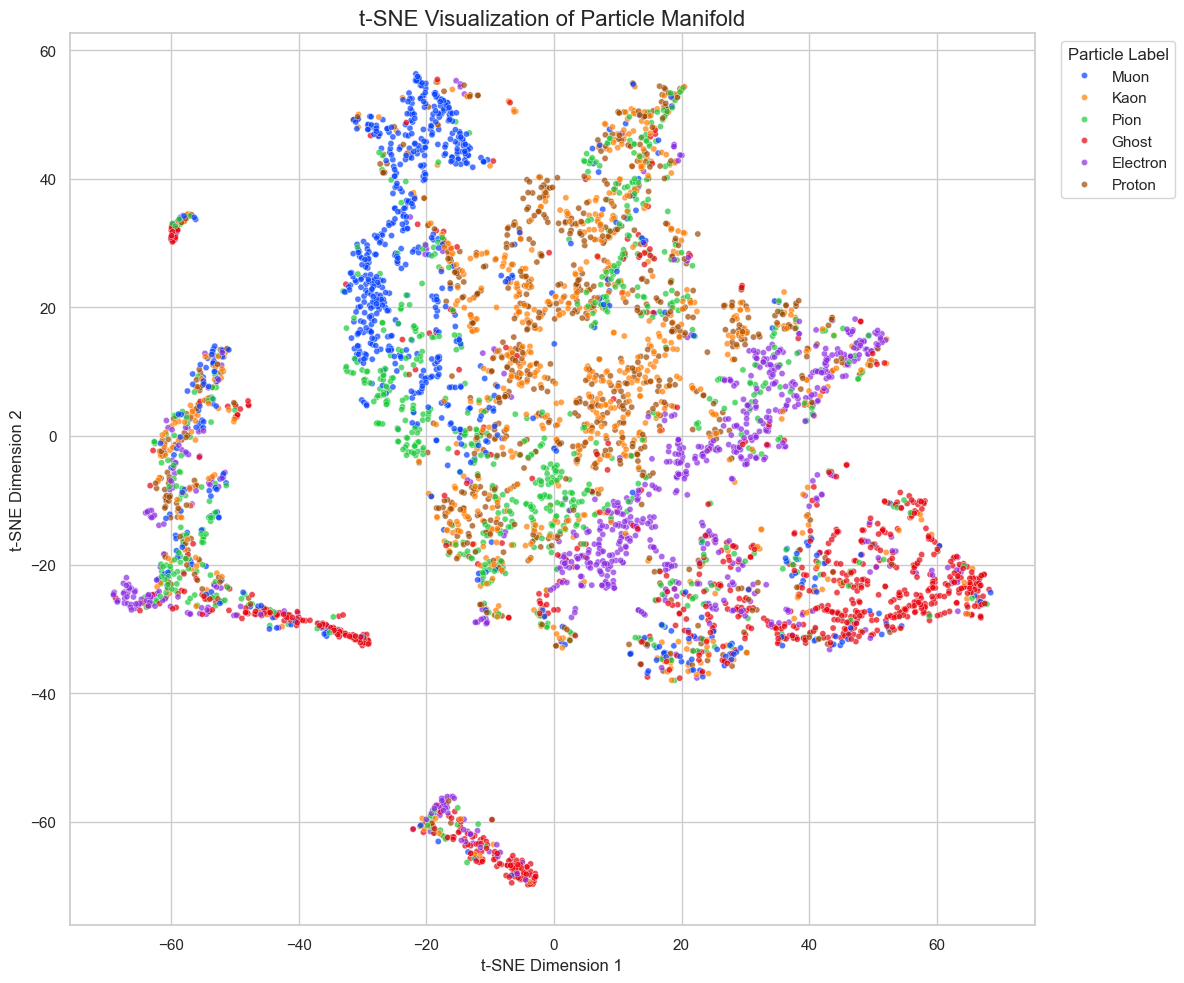

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. 분석에 사용할 주요 Feature 선정 (물리적 의미가 큰 것들 위주)
# Raw 물리량 + PID 정보(DLL)를 혼합하여 모델이 보는 뷰를 흉내냅니다.
selected_features = [
    'TrackP', 'TrackPt',            # 운동학적 변수 (Kinematics)
    'EcalE', 'HcalE', 'PrsE',       # 칼로리미터 에너지 (Calorimetry)
    'GhostProbability',             # 노이즈 확률 (중요!)
    'DLLelectron', 'DLLmuon',       # 입자 식별 우도 (PID Likelihoods)
    'DLLkaon', 'DLLproton',
    'RICH_DLLbeElectron',           # RICH 검출기 변수
    'RICH_DLLbeKaon'
]

# 데이터 샘플링 (t-SNE는 계산 비용이 높으므로 5,000개만 먼저 시각화)
df_sample = df_train.sample(n=5000, random_state=42).copy()

# 2. 데이터 정규화 (Standard Scaling)
# 에너지(수천)와 확률(0~1)의 스케일 차이를 없앱니다.
X = df_sample[selected_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. t-SNE 실행 (2차원으로 압축)
print("t-SNE 계산 중... 잠시만 기다려주세요.")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_scaled)

# 4. 시각화 데이터프레임 생성
df_tsne = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
df_tsne['Label'] = df_sample['Label'].values  # 정답 라벨 붙이기

# 5. 그래프 그리기
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_tsne,
    x='Dim1',
    y='Dim2',
    hue='Label',
    palette='bright',  # 색상 구분이 잘 되는 팔레트
    s=20,
    alpha=0.7,
    legend='full'
)
plt.title('t-SNE Visualization of Particle Manifold', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Particle Label', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

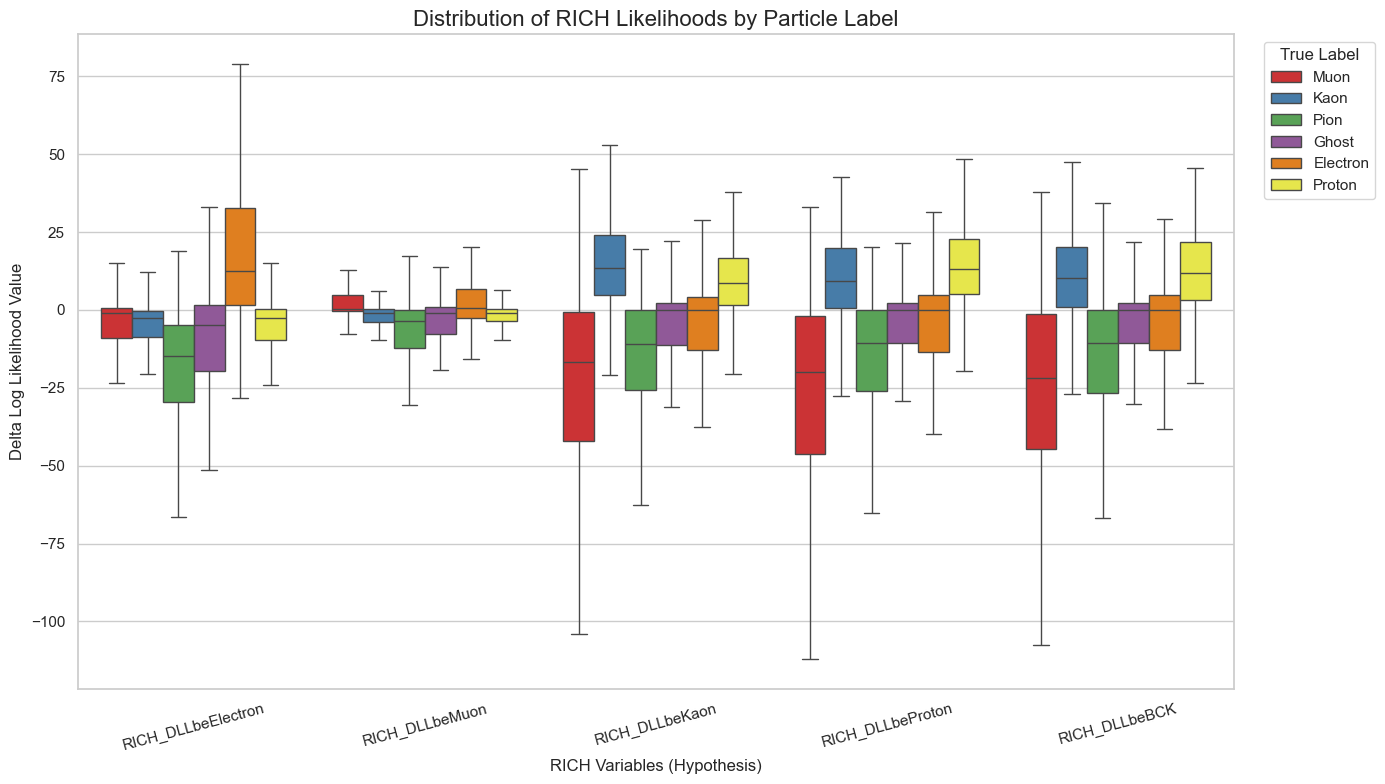

In [57]:
# RICH 관련 컬럼 자동 추출
rich_cols = ['RICH_DLLbeElectron', 'RICH_DLLbeMuon', 'RICH_DLLbeKaon', 'RICH_DLLbeProton', 'RICH_DLLbeBCK']

# 시각화를 위해 데이터 형태 변환 (Wide -> Long)
df_rich = df_sample[['Label'] + rich_cols].melt(
    id_vars=['Label'], 
    value_vars=rich_cols, 
    var_name='RICH_Variable', 
    value_name='Likelihood_Value'
)

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_rich, 
    x='RICH_Variable', 
    y='Likelihood_Value', 
    hue='Label', 
    palette='Set1',
    showfliers=False  # 이상치 제외하고 분포 중심 확인
)
plt.title('Distribution of RICH Likelihoods by Particle Label', fontsize=16)
plt.xticks(rotation=15)
plt.xlabel('RICH Variables (Hypothesis)', fontsize=12)
plt.ylabel('Delta Log Likelihood Value', fontsize=12)
plt.legend(title='True Label', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 전처리

In [59]:
from sklearn.impute import SimpleImputer

# Tree 모델용 처리
def tree_preprocess(df):
    df_tree = df.copy()
    # -999를 NaN으로 변환
    df_tree.replace(-999.0, np.nan, inplace=True)
    return df_tree

df_tree = tree_preprocess(df_train)


# 신경망용 전처리 함수 예시
def preprocess_for_nn(df):
    df_nn = df.copy()
    
    # -999를 NaN으로 변환
    df_nn.replace(-999.0, np.nan, inplace=True)
    
    # 결측치가 있는 컬럼 찾기
    missing_cols = df_nn.columns[df_nn.isna().any()].tolist()
    
    for col in missing_cols:
        # 1. Flagging: 결측치였던 곳을 1, 아니면 0으로 표시하는 새 feature 생성
        df_nn[f'{col}_is_missing'] = df_nn[col].isna().astype(int)
        
        # 2. Imputation: 결측치를 채움
        # 물리적으로 '신호 없음'은 0이나 최솟값이 타당할 때가 많음
        # 여기서는 안전하게 '평균' 혹은 '0' 중 선택 (변수 성격에 따라 다름)
        
        # Case 1: 에너지나 갯수 등 (0이 물리적 의미를 가질 때)
        if 'Ecal' in col or 'Hcal' in col or 'Num' in col:
            fill_val = 0
        # Case 2: Likelihood나 비율 등 (0이 중간값일 수 있을 때 -> 최솟값이나 평균)
        else:
            fill_val = df_nn[col].mean() # 혹은 df_nn[col].min()
            
        df_nn[col] = df_nn[col].fillna(fill_val)
        
    return df_nn

# 적용
df_mlp = preprocess_for_nn(df_train)

--- 전처리 시작: Quantile Transformer (Gaussian Output) ---
데이터 샘플 수: 1200000
설정된 n_quantiles: 1000


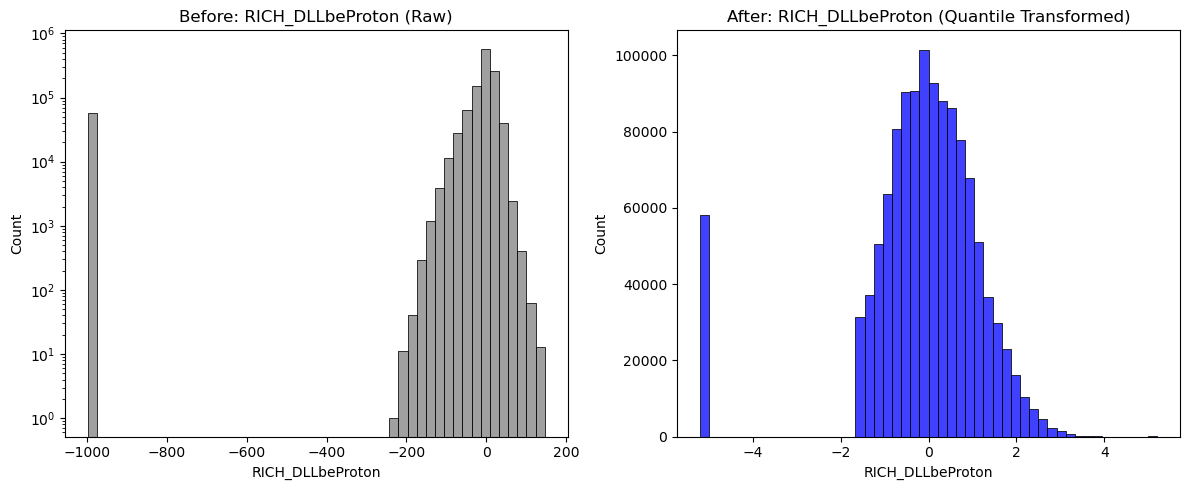

전처리 완료. X_transformed로 학습을 진행하세요.


In [ ]:
from sklearn.preprocessing import QuantileTransformer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns



# 1. 데이터 준비 (이전과 동일)
X_input = df_train.drop(['Label'], axis=1)
numeric_cols = X_input.select_dtypes(include=[np.number]).columns

print("--- 전처리 시작: Quantile Transformer (Gaussian Output) ---")

# [수정됨] 안전한 n_quantiles 설정
# 데이터 샘플 수보다 n_quantiles가 클 수 없으므로, min() 함수로 안전장치 마련
# 보통 1,000개 구간이면 분포를 표현하기에 충분히 정밀합니다.
n_samples = len(X_input)
safe_n_quantiles = min(n_samples, 1000) 

print(f"데이터 샘플 수: {n_samples}")
print(f"설정된 n_quantiles: {safe_n_quantiles}")

# 2. QuantileTransformer 설정
# subsample: 데이터가 너무 많을 때 속도를 위해 샘플링하는 개수 (기본값 100,000)
# n_quantiles: 분포를 쪼개는 구간의 수
qt = QuantileTransformer(
    output_distribution='normal', 
    n_quantiles=safe_n_quantiles, 
    random_state=42
)

# 3. 변환 수행
X_transformed = X_input.copy()
X_transformed[numeric_cols] = qt.fit_transform(X_input[numeric_cols])

# 4. 결과 검증 (시각화)
# 예시: TrackP (운동량) 분포 비교
col_name = 'RICH_DLLbeProton'

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 원본
sns.histplot(X_input[col_name], bins=50, ax=ax[0], color='gray')
ax[0].set_title(f'Before: {col_name} (Raw)')
ax[0].set_yscale('log')

# 변환 후 (왼쪽 끝에 -999가 모여있는지, 나머지는 정규분포인지 확인)
sns.histplot(X_transformed[col_name], bins=50, ax=ax[1], color='blue')
ax[1].set_title(f'After: {col_name} (Quantile Transformed)')

plt.tight_layout()
plt.show()

print("전처리 완료. X_transformed로 학습을 진행하세요.")

In [60]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os



df = train_df.copy()

# [2] 전처리: Quantile Transformation
print("🔄 전처리 진행 중 (Quantile Transformation)...")

# Features와 Label 분리
X_input = df.drop(['Label'], axis=1)
y_input = df['Label']

# 숫자형 컬럼 선택
numeric_cols = X_input.select_dtypes(include=[np.number]).columns

# QuantileTransformer 설정
# n_quantiles: 데이터 개수보다 크면 안 되므로 안전장치(min) 적용
n_samples = len(X_input)
safe_n_quantiles = min(n_samples, 1000)

qt = QuantileTransformer(
    output_distribution='normal', 
    n_quantiles=safe_n_quantiles, 
    random_state=42
)

# 변환 수행
X_transformed = X_input.copy()
X_transformed[numeric_cols] = qt.fit_transform(X_input[numeric_cols])

# [3] 데이터 분할 (Train / Validation)
# Stratified Split을 위해 One-Hot Encoding 임시 사용
y_dummies = pd.get_dummies(y_input, prefix='label')

X_train, X_val, y_train_dummies, y_val_dummies = train_test_split(
    X_transformed, y_dummies, test_size=0.2, random_state=42, stratify=y_dummies
)

# [4] PyTorch Tensor 변환
# Features
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)

# Labels: CrossEntropyLoss는 Class Index(0, 1, 2...)를 원하므로 argmax로 변환
y_train_indices = torch.tensor(y_train_dummies.values, dtype=torch.long).argmax(dim=1)
y_val_indices = torch.tensor(y_val_dummies.values, dtype=torch.long).argmax(dim=1)

# DataLoader 생성
BATCH_SIZE = 256
train_dataset = TensorDataset(X_train_tensor, y_train_indices)
val_dataset = TensorDataset(X_val_tensor, y_val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"📊 학습 데이터 준비 완료: Train {len(X_train)}개, Val {len(X_val)}개")

# [5] 모델 정의: DeepParticleClassifier (4-Layer)
class DeepParticleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DeepParticleClassifier, self).__init__()
        self.layers = nn.Sequential(
            # Layer 1: Input -> 256
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            # Layer 2: 256 -> 128
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            # Layer 3: 128 -> 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            # Output Layer: 64 -> Classes
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.layers(x)

# 장치 설정 (MPS 지원)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"💻 사용 장치: {device}")

# 모델 초기화
input_dim = X_train.shape[1]
output_dim = 6 # Class 개수
model = DeepParticleClassifier(input_dim, output_dim).to(device)

# [6] 학습 설정
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
# 스케줄러: Val Loss가 3번 안 줄어들면 LR 절반 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

# [7] 학습 루프
EPOCHS = 30
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("\n🚀 학습 시작...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    
    # Scheduler Update & LR Check
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.6f}")
            
print("✅ 학습 종료.")

# [8] 결과 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

🔄 전처리 진행 중 (Quantile Transformation)...
📊 학습 데이터 준비 완료: Train 960000개, Val 240000개
💻 사용 장치: mps

🚀 학습 시작...
Epoch [1/30] Train Loss: 0.6884 | Val Loss: 0.6028 | Val Acc: 75.13% | LR: 0.001000
Epoch [2/30] Train Loss: 0.6366 | Val Loss: 0.5889 | Val Acc: 75.45% | LR: 0.001000
Epoch [3/30] Train Loss: 0.6257 | Val Loss: 0.5836 | Val Acc: 75.63% | LR: 0.001000
Epoch [4/30] Train Loss: 0.6189 | Val Loss: 0.5798 | Val Acc: 75.81% | LR: 0.001000
Epoch [5/30] Train Loss: 0.6151 | Val Loss: 0.5809 | Val Acc: 75.86% | LR: 0.001000
Epoch [6/30] Train Loss: 0.6118 | Val Loss: 0.5762 | Val Acc: 75.95% | LR: 0.001000
Epoch [7/30] Train Loss: 0.6102 | Val Loss: 0.5732 | Val Acc: 76.08% | LR: 0.001000
Epoch [8/30] Train Loss: 0.6083 | Val Loss: 0.5717 | Val Acc: 76.16% | LR: 0.001000
Epoch [9/30] Train Loss: 0.6062 | Val Loss: 0.5702 | Val Acc: 76.16% | LR: 0.001000
Epoch [10/30] Train Loss: 0.6051 | Val Loss: 0.5708 | Val Acc: 76.14% | LR: 0.001000
Epoch [11/30] Train Loss: 0.6040 | Val Loss: 0.5700

KeyboardInterrupt: 

Model Training Started...
[0]	validation_0-mlogloss:1.71260
[50]	validation_0-mlogloss:0.74077
[100]	validation_0-mlogloss:0.63861
[150]	validation_0-mlogloss:0.60801
[200]	validation_0-mlogloss:0.59081
[250]	validation_0-mlogloss:0.57861
[300]	validation_0-mlogloss:0.57011
[350]	validation_0-mlogloss:0.56383
[400]	validation_0-mlogloss:0.55887
[450]	validation_0-mlogloss:0.55478
[499]	validation_0-mlogloss:0.55144

[Evaluation Results]
Validation Accuracy: 0.7756


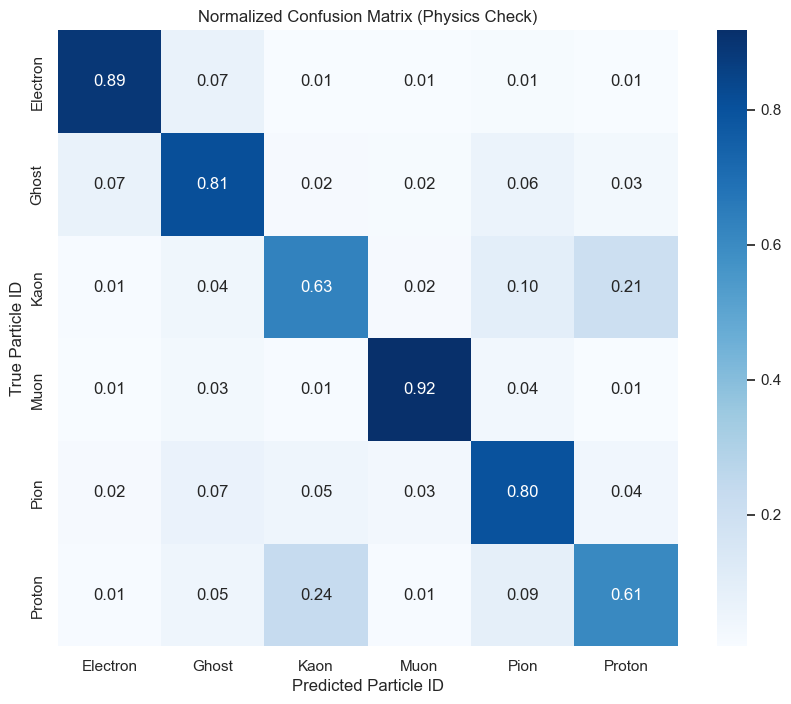

<Figure size 1200x800 with 0 Axes>

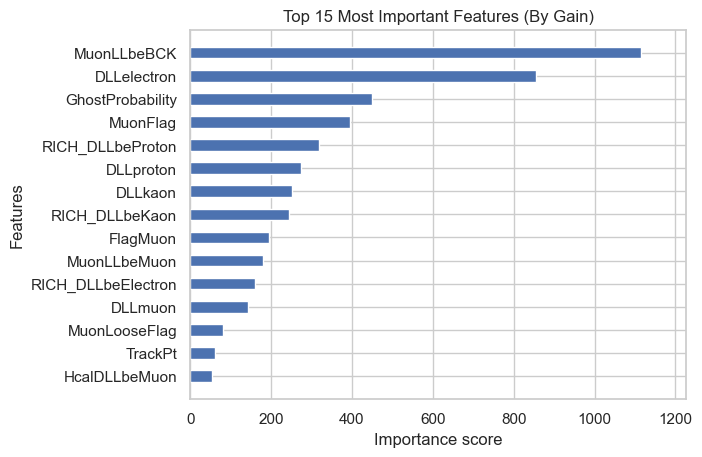

In [62]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 데이터 준비 및 전처리
# 원본 데이터 보존을 위해 카피
df_model = df_train.copy()

# -999.0을 np.nan으로 변경 (XGBoost가 결측치로 인식하도록)
df_model.replace(-999.0, np.nan, inplace=True)

# Feature와 Label 분리
# User가 제공한 컬럼 리스트에 'Label'이 있었으므로 이를 타겟으로 설정
label_col = 'Label'
X = df_model.drop(columns=[label_col])
y = df_model[label_col]

# Label Encoding (혹시 클래스가 0부터 시작하지 않을 경우를 대비)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = [str(c) for c in le.classes_] # 나중에 시각화용

# Train / Validation Split (8:2)
# stratify=y_encoded 옵션은 클래스 비율을 유지하면서 자르기 위함 (중요!)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2. XGBoost 모델 설정 및 학습
print("Model Training Started...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=500,           # 트리 개수 (충분히 크게 잡고 early_stopping으로 제어)
    learning_rate=0.05,         # 학습률
    max_depth=6,                # 트리의 깊이 (너무 깊으면 과적합)
    objective='multi:softprob', # 다중 분류 확률값 출력
    num_class=len(class_names), # 클래스 개수
    tree_method='hist',         # 결측치 처리에 최적화된 고속 알고리즘
    random_state=42,
    early_stopping_rounds=20,
    n_jobs=-1                   # 모든 CPU 코어 사용
)

# 학습 (Validation Loss가 더 이상 안 줄어들면 조기 종료)
xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50 # 50번마다 로그 출력
)

# 3. 평가 및 검증
print("\n[Evaluation Results]")
y_pred = xgb_clf.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")

# --- 시각화 1: Confusion Matrix (어떤 입자를 헷갈려하는가?) ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
# 값을 비율로 표시하여 클래스 불균형 영향 최소화
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Physics Check)')
plt.ylabel('True Particle ID')
plt.xlabel('Predicted Particle ID')
plt.show()

# --- 시각화 2: Feature Importance (모델은 무엇을 중요하게 봤는가?) ---
plt.figure(figsize=(12, 8))
# Gain: 해당 변수가 쓰였을 때 손실 함수(Loss)를 얼마나 줄였는가 (정보 이득)
xgb.plot_importance(xgb_clf, importance_type='gain', max_num_features=15, height=0.5, show_values=False)
plt.title('Top 15 Most Important Features (By Gain)')
plt.show()